In [57]:
import numpy as np
import pandas as pd
import duckdb
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
print(f"I am currently in: {os.getcwd()}")
print(f"Files I can see here: {os.listdir('.')}")

I am currently in: C:\dev\AAV_Process_Modeling\notebooks
Files I can see here: ['.ipynb_checkpoints', '2026_04_13_generate_data.ipynb', '2026_04_19_query_tests.ipynb', 'aav_manufacturing.db']


While this pipeline uses Pandas for 50 batches, for industrial scale (10,000+ batches), 
I would implement a Partitioned Processing strategy or SQL-side Window Functions 
to minimize memory overhead and ensure the 'Digital Twin' creation remains performant.

In [67]:
# Connect to the DB file in your current folder
con = duckdb.connect('aav_manufacturing.db')

query = """
    SELECT 
    Hour,
    Batch_ID, 
    VCD, 
    Glucose, 
    Lactate, 
    Ammonia, 
    Product,
    FROM telemetry 
    """

df_messy = con.execute(query).df()
# 1. Define a clean 1-hour grid
clean_grid = np.arange(0, 241, 1)

# We isolate the numeric columns so 'Batch_ID' doesn't cause a warning
cols_to_sync = ['VCD', 'Glucose', 'Lactate', 'Ammonia', 'Product']

df_cleaned = (
    df_messy
    .groupby('Batch_ID')
    .apply(
        lambda x: x.set_index('Hour')[cols_to_sync]
                 .reindex(clean_grid)
                 .infer_objects(copy=False)
                 .interpolate(method='linear')
                 .ffill()
                 .bfill(),
        include_groups=False # This is the specific fix for the new warning
    )
    .reset_index()
)

In [50]:
# Get the path of the folder holding this notebook, then go up one
project_root = os.path.dirname(os.getcwd())

# Connect to a database file (this creates it if it doesn't exist)
con = duckdb.connect('../aav_manufacturing.db') 

# 1. Create or replace the Telemetry and outcomes tables directly from the CSV
con.execute(f"CREATE OR REPLACE TABLE telemetry AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'telemetry_batches.csv')}'")
con.execute(f"CREATE OR REPLACE TABLE outcomes AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'batch_outcomes.csv')}'")

print(con.execute("SHOW TABLES").fetchall())

#close the connection to spare resources
con.close()

[('outcomes',), ('telemetry',)]


,Batch_ID,Hour,VCD,Glucose,Lactate,Ammonia,Product
0,LOT_000,0,0.771787,25.000000,0.0000,0.000000,0.000000
1,LOT_000,1,0.812230,24.895833,0.1875,0.020833,0.007684
2,LOT_000,2,0.852673,24.791667,0.3750,0.041667,0.015368
3,LOT_000,3,0.893116,24.687500,0.5625,0.062500,0.023052
4,LOT_000,4,0.933558,24.583333,0.7500,0.083333,0.030736


In [53]:
# Query the top 5 batches by Titer
query = """
    SELECT Batch_ID, Final_Titer, Full_Empty_Ratio 
    FROM outcomes 
    ORDER BY Final_Titer DESC 
    LIMIT 5
    """

df_top = con.execute(query).df()
print("Top Performing Batches:")
display(df_top)



Top Performing Batches:


,Batch_ID,Final_Titer,Full_Empty_Ratio
0,LOT_025,1.694304,0.260982
1,LOT_010,1.686583,0.264169
2,LOT_001,1.681448,0.265977
3,LOT_026,1.640514,0.265054
4,LOT_024,1.598422,0.259548


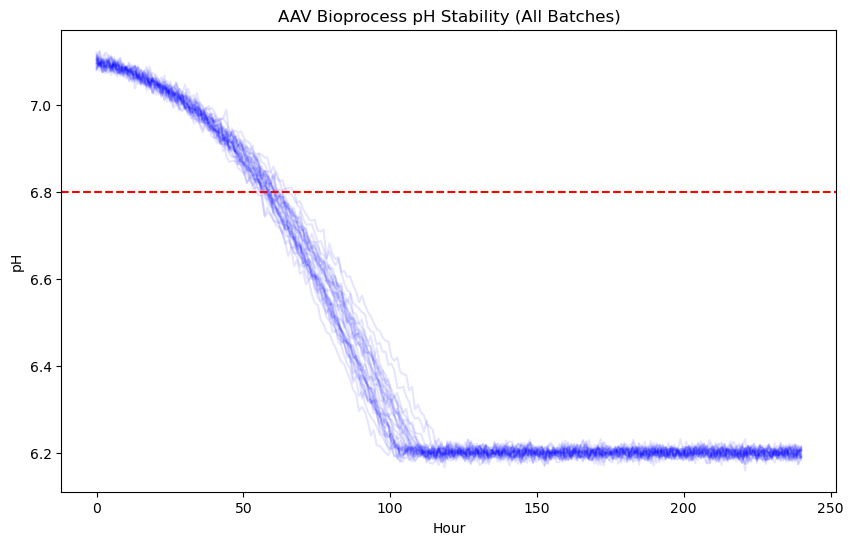

In [54]:
import matplotlib.pyplot as plt

# Pull pH data for all batches
df_ph = con.execute("SELECT Hour, pH, Batch_ID FROM telemetry").df()

plt.figure(figsize=(10, 6))
# We group by Batch_ID to plot a line for each individual run
for label, df in df_ph.groupby('Batch_ID'):
    plt.plot(df['Hour'], df['pH'], color='blue', alpha=0.1) # alpha makes lines semi-transparent

plt.axhline(y=6.8, color='red', linestyle='--', label='Critical pH Threshold')
plt.title('AAV Bioprocess pH Stability (All Batches)')
plt.xlabel('Hour')
plt.ylabel('pH')
plt.show()

In [11]:
#creates an index to make the query faster
con.execute("CREATE INDEX idx_batch_id ON telemetry (Batch_ID);")

ConnectionException: Connection Error: Connection already closed!

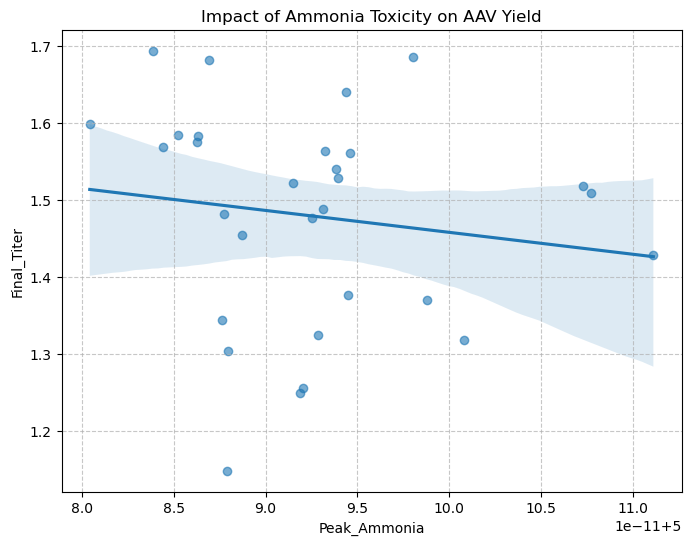

In [48]:
# 1. Join the tables directly in SQL (Much faster than pd.merge)
query = """
SELECT 
    o.Batch_ID, 
    o.Final_Titer, 
    MAX(t.Ammonia) AS Peak_Ammonia
FROM outcomes o
JOIN telemetry t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Final_Titer
"""

df_corr = con.execute(query).df()

# 2. Visualize the relationship
plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr, x='Peak_Ammonia', y='Final_Titer', scatter_kws={'alpha':0.6})

plt.title('Impact of Ammonia Toxicity on AAV Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [15]:
query = """
SELECT 
    t.Hour,
    t.pH,
    t.VCD, 
    t.Glucose, 
    t.Lactate, 
    t.Ammonia, 
    t.Product
FROM telemetry t 
WHERE t.Batch_ID = 'LOT_025'
"""

df_culture_graph = con.execute(query).df()

In [17]:
df_culture_graph.head()

,Hour,pH,VCD,Glucose,Lactate,Ammonia,Product
0,0.000000,7.107697,0.526889,25.000000,0.000000,0.000000,0.0
1,1.004184,7.108632,0.707473,24.948724,0.092297,0.010255,0.0
2,2.008368,7.104122,0.517624,24.895474,0.188147,0.020905,0.0
3,3.012552,7.086262,0.700914,24.840185,0.287668,0.031963,0.0
4,4.016736,7.096544,0.455493,24.782789,0.390980,0.043442,0.0


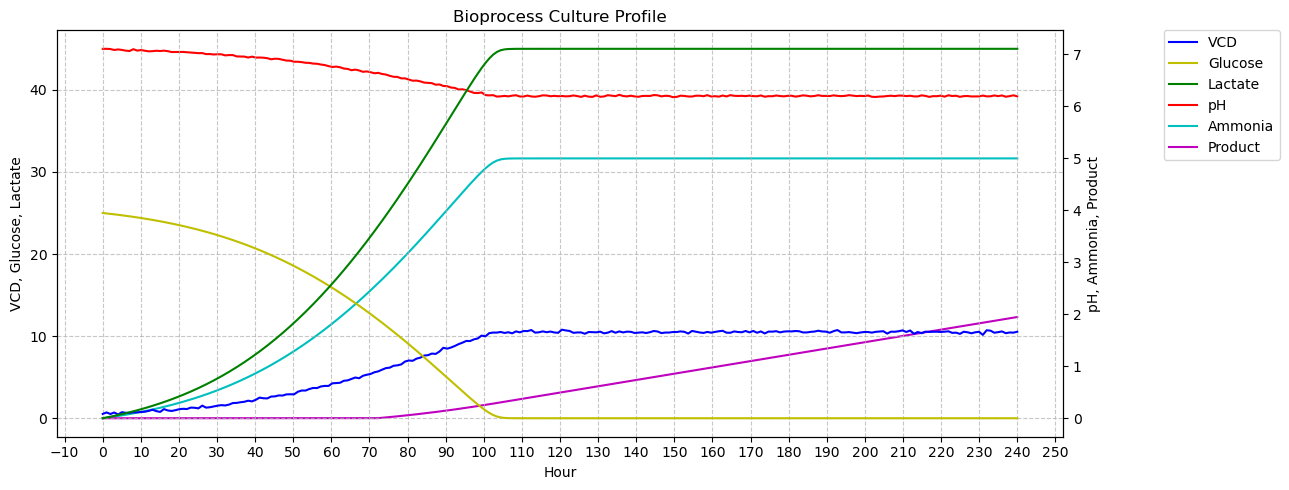

In [55]:
import matplotlib.ticker as ticker

# pH, ammonia and product on secondary axis
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.set_ylabel('VCD, Glucose, Lactate')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
colors_1 = ("b","y", "g")
df_culture_graph.plot(x='Hour', y = ["VCD", "Glucose", "Lactate"], color=colors_1, ax= ax1)

ax2 = ax1.twinx()
ax2.set_ylabel('pH, Ammonia, Product')
colors_2 = ("r","c","m")
df_culture_graph.plot(x='Hour', y = ["pH", "Ammonia", "Product"], color=colors_2, ax= ax2)

ax1.set_zorder(ax2.get_zorder() + 1) 
# Make ax1's background transparent so we can see ax2 behind it
ax1.patch.set_visible(False) 
# Explicitly turn on the grid for the front layer (ax1)
ax1.grid(True, linestyle='--', alpha=0.7)

# Get legends from both axes and combine them
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Remove the individual legends created by Pandas
ax1.get_legend().remove()
ax2.get_legend().remove()

# Create one single unified legend
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', bbox_to_anchor=(1.1, 1), borderaxespad=0.)

plt.title('Bioprocess Culture Profile')
plt.tight_layout()
plt.show()

In [10]:
con.close()